# Phase 2: Advanced Visualizations (Y2-01 to Y2-02)

**Assignment:** DAT2061 COVID-19 Data Visualization

**Phase 2 Objectives:**
- Y2-01: Advanced statistical plots (violin, heatmap, radial)
- Y2-02: Interactive and geographic visualizations

**Data Source:** data/processed/covid_cleaned.csv

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

# Output directory
OUTPUT_DIR = '../../outputs/visualizations/phase2/'

print("Setup complete!")

Setup complete!


## Load Processed Data

In [2]:
# Load processed data
df = pd.read_csv('../../data/processed/covid_cleaned.csv')
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

print(f"Loaded {len(df)} records")
print(f"Countries: {df['Country/Region'].nunique()}")
df.head()

Loaded 306429 records
Countries: 224


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,Active,DeathRate,RecoveryRate,ActiveRate,DailyConfirmed,DailyDeaths,DailyRecovered,IsOutlier,IsHighValue
0,2325,2020-02-24,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
1,2420,2020-02-25,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
2,2523,2020-02-26,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
3,2629,2020-02-27,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
4,2739,2020-02-28,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False


---
# Y2-01: Advanced Statistical Plots

**Objective:** Deep distribution analysis using violin plots, heatmaps, and radial visualizations

## 1.1 Violin Plots - Distribution Comparison

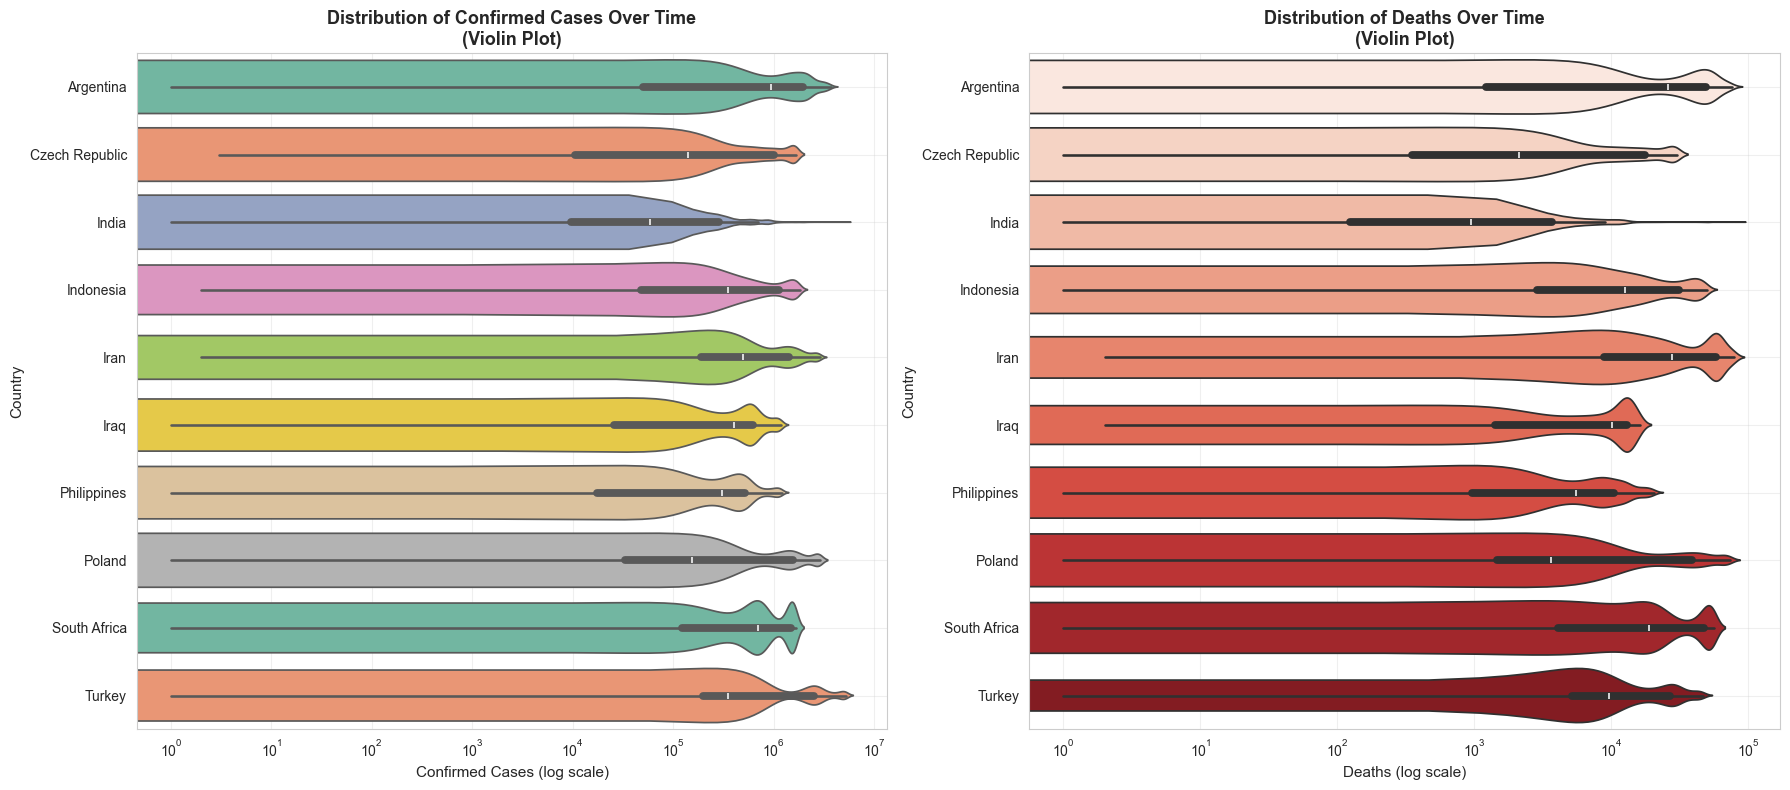

In [3]:
# Get latest data for top countries
latest = df.groupby('Country/Region').last().reset_index()
top_countries = latest.nlargest(10, 'Confirmed')['Country/Region'].values

# Filter data for top countries
violin_data = df[df['Country/Region'].isin(top_countries)].copy()
violin_data = violin_data[violin_data['Confirmed'] > 0]

# Create violin plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Violin plot for confirmed cases (log scale)
sns.violinplot(data=violin_data, y='Country/Region', x='Confirmed', ax=axes[0], palette='Set2')
axes[0].set_xscale('log')
axes[0].set_xlabel('Confirmed Cases (log scale)', fontsize=11)
axes[0].set_ylabel('Country', fontsize=11)
axes[0].set_title('Distribution of Confirmed Cases Over Time\n(Violin Plot)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Violin plot for deaths (log scale)
violin_deaths = violin_data[violin_data['Deaths'] > 0]
sns.violinplot(data=violin_deaths, y='Country/Region', x='Deaths', ax=axes[1], palette='Reds')
axes[1].set_xscale('log')
axes[1].set_xlabel('Deaths (log scale)', fontsize=11)
axes[1].set_ylabel('Country', fontsize=11)
axes[1].set_title('Distribution of Deaths Over Time\n(Violin Plot)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y2_01_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.2 Heatmap - Spread Rates Across Regions

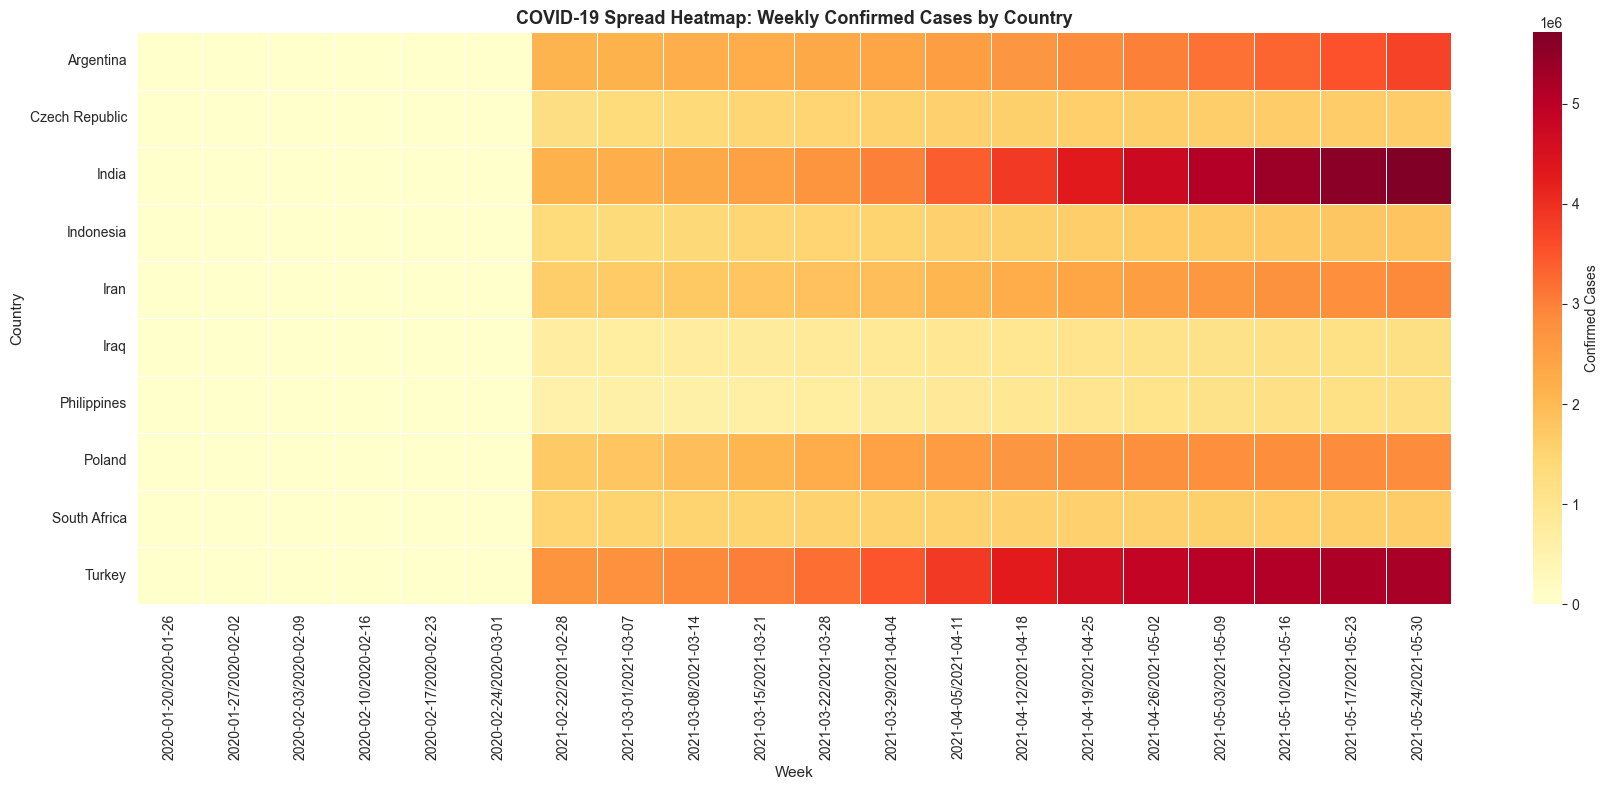

In [4]:
# Create pivot table for heatmap (weekly confirmed cases)
df['Week'] = df['ObservationDate'].dt.to_period('W')
weekly_data = df[df['Country/Region'].isin(top_countries)].groupby(
    ['Country/Region', 'Week'])['Confirmed'].max().reset_index()

# Get last 20 weeks for better visualization
recent_weeks = weekly_data['Week'].unique()[-20:]
heatmap_data = weekly_data[weekly_data['Week'].isin(recent_weeks)]

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='Country/Region', columns='Week', values='Confirmed')
heatmap_pivot = heatmap_pivot.fillna(0)

# Create heatmap
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Confirmed Cases'}, ax=ax)

ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.set_title('COVID-19 Spread Heatmap: Weekly Confirmed Cases by Country', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y2_01_heatmap_spread.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Radial Plot - Death Rates by Region

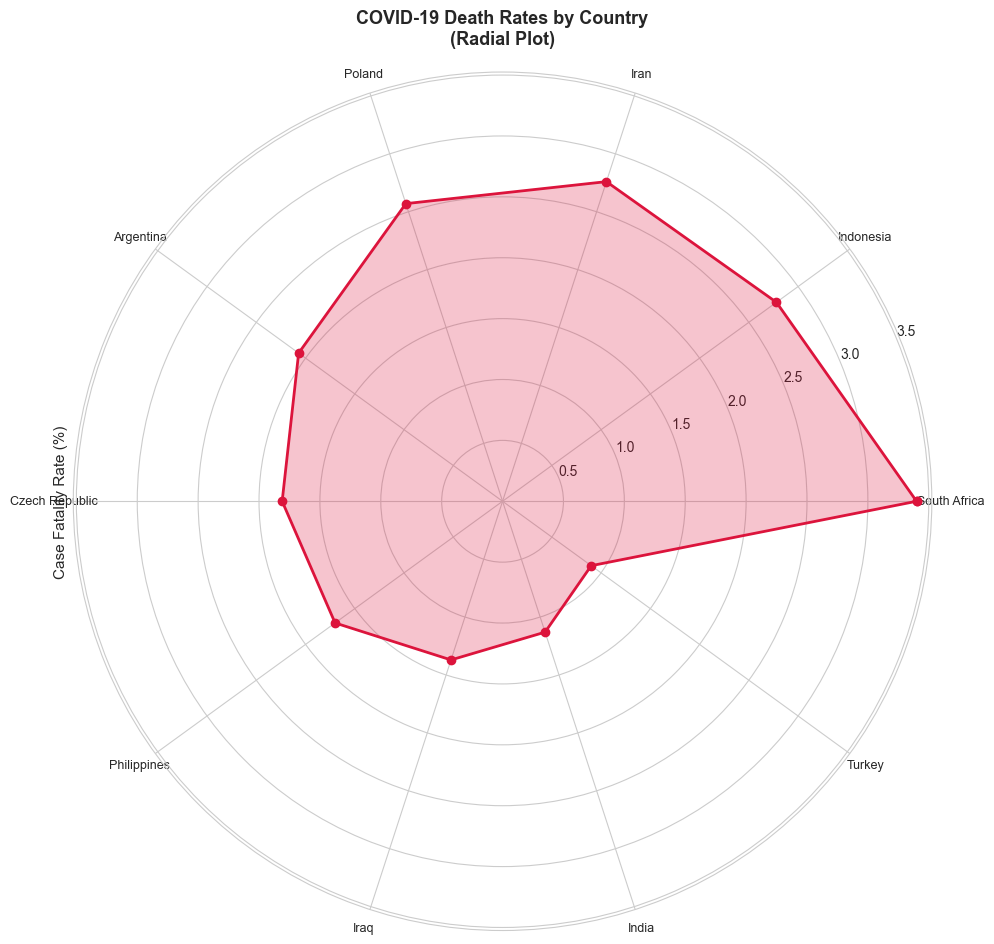

In [5]:
# Calculate death rate (CFR) for top countries
latest_cfr = latest[latest['Country/Region'].isin(top_countries)].copy()
latest_cfr['CFR'] = (latest_cfr['Deaths'] / latest_cfr['Confirmed'] * 100).round(2)
latest_cfr = latest_cfr.sort_values('CFR', ascending=False)

# Create radial (polar) plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Set up angles
angles = np.linspace(0, 2 * np.pi, len(latest_cfr), endpoint=False).tolist()
values = latest_cfr['CFR'].tolist()
countries = latest_cfr['Country/Region'].tolist()

# Close the plot
angles += angles[:1]
values += values[:1]

# Plot
ax.plot(angles, values, 'o-', linewidth=2, color='crimson')
ax.fill(angles, values, alpha=0.25, color='crimson')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(countries, fontsize=9)
ax.set_ylabel('Case Fatality Rate (%)', fontsize=11)
ax.set_title('COVID-19 Death Rates by Country\n(Radial Plot)', fontsize=13, fontweight='bold', pad=20)
ax.grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y2_01_radial_death_rates.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Y2-02: Interactive and Geographic Visualizations

**Objective:** Create interactive charts with region selection and geographic maps

## 2.1 Interactive Time Series with Region Selection

In [6]:
# Prepare data for interactive plot
country_ts = df.groupby(['ObservationDate', 'Country/Region']).agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).reset_index()

# Filter to top countries for performance
interactive_data = country_ts[country_ts['Country/Region'].isin(top_countries)]

# Create interactive line chart
fig = px.line(interactive_data, 
              x='ObservationDate', 
              y='Confirmed',
              color='Country/Region',
              title='Interactive COVID-19 Timeline: Confirmed Cases by Country',
              labels={'ObservationDate': 'Date', 'Confirmed': 'Confirmed Cases'},
              hover_data=['Deaths', 'Recovered'])

fig.update_layout(
    hovermode='x unified',
    height=600,
    xaxis_title='Date',
    yaxis_title='Confirmed Cases',
    legend_title='Country'
)

fig.write_html(OUTPUT_DIR + 'y2_02_interactive_timeline.html')
fig.show()

print("Interactive chart saved to:", OUTPUT_DIR + 'y2_02_interactive_timeline.html')

Interactive chart saved to: ../../outputs/visualizations/phase2/y2_02_interactive_timeline.html


## 2.2 Animated Bubble Chart

In [7]:
# Create animated bubble chart showing confirmed vs deaths over time
bubble_data = df[df['Country/Region'].isin(top_countries)].copy()
bubble_data = bubble_data[bubble_data['Confirmed'] > 0]

fig = px.scatter(bubble_data,
                 x='Confirmed',
                 y='Deaths',
                 animation_frame=bubble_data['ObservationDate'].dt.strftime('%Y-%m-%d'),
                 size='Recovered',
                 color='Country/Region',
                 hover_name='Country/Region',
                 log_x=True,
                 log_y=True,
                 size_max=50,
                 title='Animated COVID-19 Bubble Chart: Confirmed vs Deaths Over Time')

fig.update_layout(height=700)
fig.write_html(OUTPUT_DIR + 'y2_02_animated_bubble.html')
fig.show()

print("Animated bubble chart saved to:", OUTPUT_DIR + 'y2_02_animated_bubble.html')

Animated bubble chart saved to: ../../outputs/visualizations/phase2/y2_02_animated_bubble.html


## 2.3 Geographic Choropleth Map

In [8]:
# Get latest data for map
map_data = df.groupby('Country/Region').last().reset_index()

# Create choropleth map
fig = px.choropleth(map_data,
                    locations='Country/Region',
                    locationmode='country names',
                    color='Confirmed',
                    hover_name='Country/Region',
                    hover_data={'Confirmed': ':,', 'Deaths': ':,', 'Recovered': ':,'},
                    color_continuous_scale='Reds',
                    title='Global COVID-19 Impact: Confirmed Cases by Country')

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    height=600
)

fig.write_html(OUTPUT_DIR + 'y2_02_choropleth_map.html')
fig.show()

print("Choropleth map saved to:", OUTPUT_DIR + 'y2_02_choropleth_map.html')

Choropleth map saved to: ../../outputs/visualizations/phase2/y2_02_choropleth_map.html


## 2.4 Interactive Dashboard

In [9]:
# Create comprehensive dashboard with subplots
from plotly.subplots import make_subplots

dashboard_data = country_ts[country_ts['Country/Region'].isin(top_countries[:5])]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Confirmed Cases Over Time', 'Deaths Over Time',
                    'Recovery Rate', 'Case Fatality Rate'),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# Add traces for each country
for country in top_countries[:5]:
    country_data = dashboard_data[dashboard_data['Country/Region'] == country]
    
    # Confirmed cases
    fig.add_trace(
        go.Scatter(x=country_data['ObservationDate'], y=country_data['Confirmed'],
                   name=country, mode='lines'),
        row=1, col=1
    )
    
    # Deaths
    fig.add_trace(
        go.Scatter(x=country_data['ObservationDate'], y=country_data['Deaths'],
                   name=country, mode='lines', showlegend=False),
        row=1, col=2
    )

# Add bar charts for latest rates
latest_rates = latest[latest['Country/Region'].isin(top_countries[:5])].copy()
latest_rates['RecoveryRate'] = (latest_rates['Recovered'] / latest_rates['Confirmed'] * 100)
latest_rates['CFR'] = (latest_rates['Deaths'] / latest_rates['Confirmed'] * 100)

fig.add_trace(
    go.Bar(x=latest_rates['Country/Region'], y=latest_rates['RecoveryRate'],
           name='Recovery Rate', showlegend=False),
    row=2, col=1
)

fig.add_trace(
    go.Bar(x=latest_rates['Country/Region'], y=latest_rates['CFR'],
           name='CFR', showlegend=False, marker_color='crimson'),
    row=2, col=2
)

fig.update_layout(height=800, title_text='COVID-19 Interactive Dashboard')
fig.write_html(OUTPUT_DIR + 'y2_02_interactive_dashboard.html')
fig.show()

print("Interactive dashboard saved to:", OUTPUT_DIR + 'y2_02_interactive_dashboard.html')

Interactive dashboard saved to: ../../outputs/visualizations/phase2/y2_02_interactive_dashboard.html


---
## Summary

**Phase 2 Deliverables:**
- ✅ Y2-01: Advanced statistical plots (violin, heatmap, radial)
- ✅ Y2-02: Interactive and geographic visualizations

**Generated Files:**
- Static images: PNG files in `outputs/visualizations/phase2/`
- Interactive files: HTML files in `outputs/visualizations/phase2/`

**Key Insights:**
- [Document your findings here]

**Assignment Complete!**